In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment working!")

Environment working!


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression

# Optional for nice plots
sns.set(style="whitegrid")
%matplotlib inline

In [50]:
# NASA GISTEMP CSV
url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"
df = pd.read_csv(url, skiprows=1)

# Clean column names
df.columns = df.columns.str.strip()
print("Columns in dataset:", df.columns.tolist())

Columns in dataset: ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'J-D', 'D-N', 'DJF', 'MAM', 'JJA', 'SON']


In [51]:
# Keep only Year + J-D (annual mean)
df = df[['Year', 'J-D']].copy()
df.rename(columns={'J-D':'Temp_Anomaly'}, inplace=True)

# Convert to numeric, invalid values to NaN
df['Temp_Anomaly'] = pd.to_numeric(df['Temp_Anomaly'], errors='coerce')

# Interpolate missing values (linear)
df['Temp_Anomaly'] = df['Temp_Anomaly'].interpolate(method='linear')

# Fill any remaining NaNs (start/end) with median
df['Temp_Anomaly'] = df['Temp_Anomaly'].fillna(df['Temp_Anomaly'].median())

# Ensure correct type
df['Year'] = df['Year'].astype(int)
df['Temp_Anomaly'] = df['Temp_Anomaly'].astype(float)

# Confirm no missing values
print("Missing values after cleaning:", df['Temp_Anomaly'].isna().sum())

Missing values after cleaning: 0


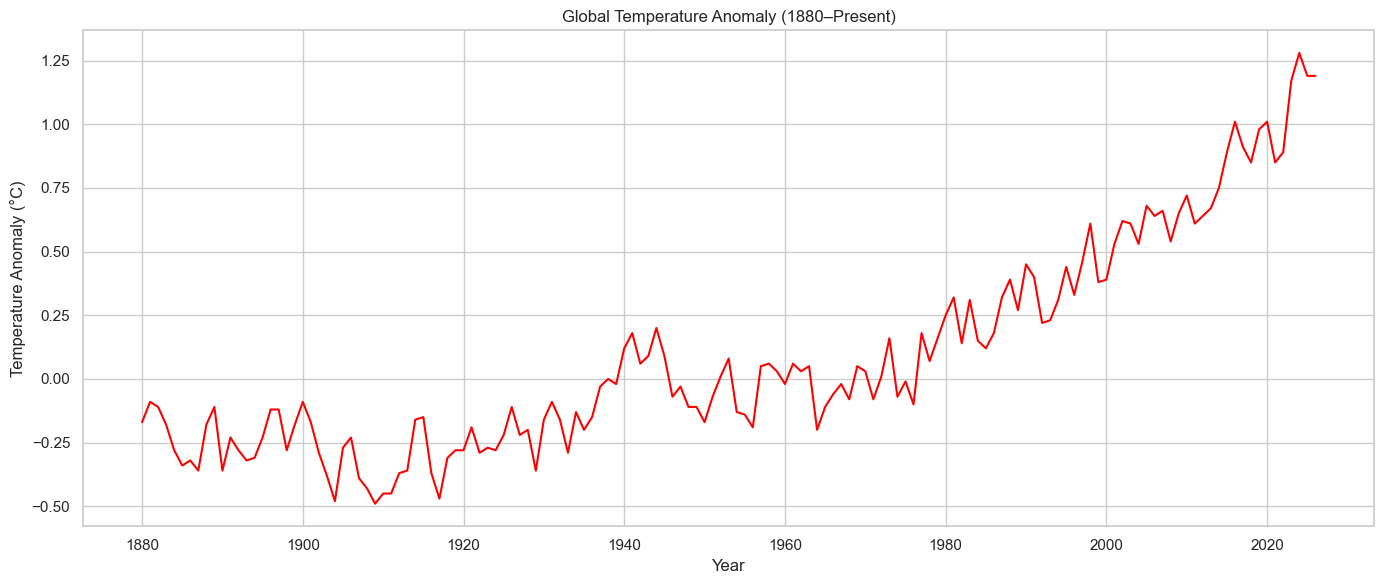

In [52]:
plt.figure(figsize=(14,6))
sns.lineplot(data=df, x='Year', y='Temp_Anomaly', color='red')
plt.title("Global Temperature Anomaly (1880–Present)")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.tight_layout()
plt.show()

C:\Users\Hussain\AppData\Local\Temp\ipykernel_1976\2373840799.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=decade_avg.index, y=decade_avg.values, palette=colors)


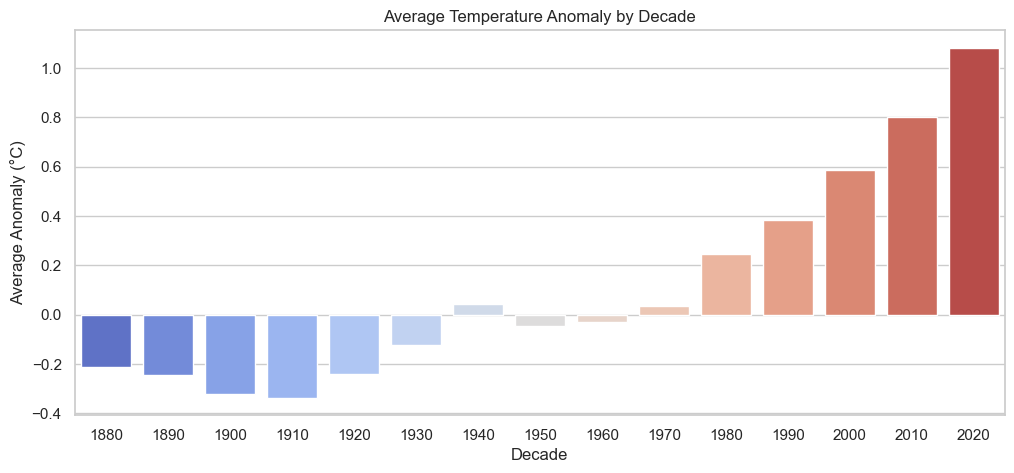

In [53]:
# Compute decade
df['Decade'] = (df['Year'] // 10) * 10
decade_avg = df.groupby('Decade')['Temp_Anomaly'].mean()

# Create color palette
colors = sns.color_palette("coolwarm", len(decade_avg))

plt.figure(figsize=(12,5))
sns.barplot(x=decade_avg.index, y=decade_avg.values, palette=colors)
plt.title("Average Temperature Anomaly by Decade")
plt.xlabel("Decade")
plt.ylabel("Average Anomaly (°C)")
plt.show()

In [54]:
top10 = df.sort_values(by='Temp_Anomaly', ascending=False).head(10)
print("Top 10 hottest years:")
print(top10[['Year','Temp_Anomaly']])

Top 10 hottest years:
     Year  Temp_Anomaly
144  2024          1.28
145  2025          1.19
146  2026          1.19
143  2023          1.17
140  2020          1.01
136  2016          1.01
139  2019          0.98
137  2017          0.91
135  2015          0.89
142  2022          0.89


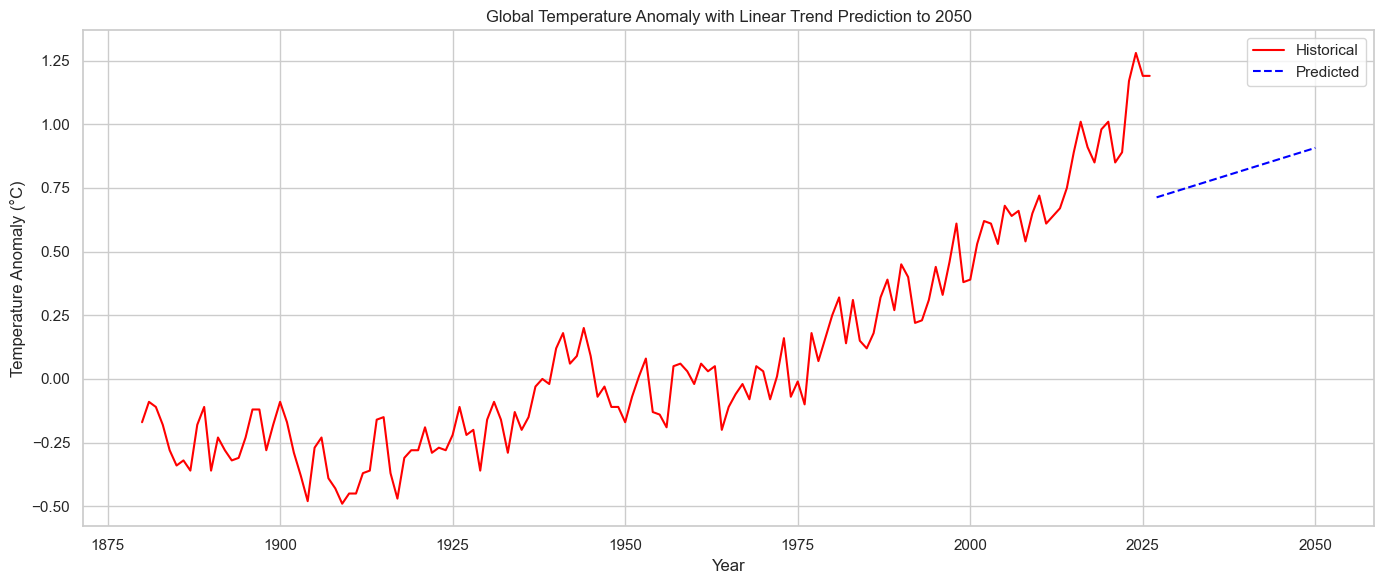

In [55]:
# Prepare data
X = df[['Year']].values  # 2D array
y = df['Temp_Anomaly'].values  # 1D array

# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Predict future
future_years = np.arange(df['Year'].max()+1, 2051).reshape(-1,1)
future_predictions = model.predict(future_years)

# Plot historical + prediction
plt.figure(figsize=(14,6))
plt.plot(df['Year'], df['Temp_Anomaly'], label='Historical', color='red')
plt.plot(future_years, future_predictions, label='Predicted', color='blue', linestyle='--')
plt.title("Global Temperature Anomaly with Linear Trend Prediction to 2050")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.legend()
plt.tight_layout()
plt.show()